In [ ]:
# Bayesian Linear Regression

In [4]:
!pip install bambi

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------- ----------------- 0.8/1.4 MB 3.8 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 4.5 MB/s eta 0:00:00

   ---------------------------------------- 0/7 [graphviz]
   ----- ---------------------------------- 1/7 [sparse]
   ----- ---------------------------------- 1/7 [sparse]
   ----- ---------------------------------- 1/7 [sparse]
   ----- ---------------------------------- 1/7 [sparse]
   ----- ---------------------------------- 1/7 [sparse]
   ----- ---------------------------------- 1/7 [sparse]
   ----- ---------------------------------- 1/7 [sparse]
   ----- ---------------------------------- 1/7 [sparse]
   ----------- ---------------------------- 2/7 [arviz-stats]
   ----------- ---------------------------- 2/7 [arviz-stats]
   ----------- ---------------------------- 2/7 [arviz-stats]
   ----------- ---------------------------- 2/7 [arviz-stats]
   ------------

In [5]:
import pandas as pd
import numpy as np
import bambi as bmb

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [6]:
# load the ugtests data from current working directory
ugtests = pd.read_csv("ugtests.csv")

# take a random sample of 100 rows
np.random.seed(123)
ugtests_bayes = ugtests.sample(n=100, random_state=123).copy()

# optional check
ugtests_bayes.head()

,Yr1,Yr2,Yr3,Final
877,31,122,113,170
764,14,59,159,174
788,32,117,108,191
727,50,116,131,183
898,58,115,112,147


In [7]:
# MCMC methods
# fit an uninformed Bayesian linear regression model
uninf_model = bmb.Model(
    formula="Final ~ Yr1 + Yr2 + Yr3",
    data=ugtests_bayes,
    family="gaussian"
)

uninf_results = uninf_model.fit(
    draws=10000,
    chains=4,
    random_seed=123
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, Yr1, Yr2, Yr3]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 1461 seconds.


In [8]:
uninf_model

       Formula: Final ~ Yr1 + Yr2 + Yr3
        Family: gaussian
          Link: mu = identity
  Observations: 100
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 154.63, sigma: 626.7374)
            Yr1 ~ Normal(mu: 0.0, sigma: 6.9113)
            Yr2 ~ Normal(mu: 0.0, sigma: 3.6767)
            Yr3 ~ Normal(mu: 0.0, sigma: 3.3494)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 44.2951)
------
* To see a plot of the priors call the .plot_priors() method.
* To see a summary or plot of the posterior pass the object returned by .fit() to az.summary() or az.plot_trace()

In [9]:
import arviz as az
az.summary(uninf_results)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,29.496,2.166,25.596,33.635,0.010,0.011,50739.0,33173.0,1.0
Intercept,23.473,16.470,-7.601,54.426,0.068,0.078,58233.0,34674.0,1.0
Yr1,0.071,0.186,-0.282,0.417,0.001,0.001,51437.0,32999.0,1.0
Yr2,0.286,0.101,0.091,0.472,0.000,0.000,47807.0,32769.0,1.0
Yr3,0.934,0.092,0.764,1.109,0.000,0.000,48485.0,33798.0,1.0


In [10]:
import numpy as np

# extract posterior draws for the Yr3 coefficient
yr3_samples = uninf_results.posterior["Yr3"].values.flatten()

# basic checks
print("number of samples:", len(yr3_samples))
print("first 10 samples:", yr3_samples[:10])
print("posterior mean:", np.mean(yr3_samples))
print("94% interval:", np.quantile(yr3_samples, [0.03, 0.97]))

number of samples: 40000
first 10 samples: [1.01669268 1.01808085 0.87915768 0.83230024 0.9553804  0.91529997
 0.95547592 1.02301477 1.08637473 0.94774135]
posterior mean: 0.9335332259587936
94% interval: [0.76051535 1.10582625]


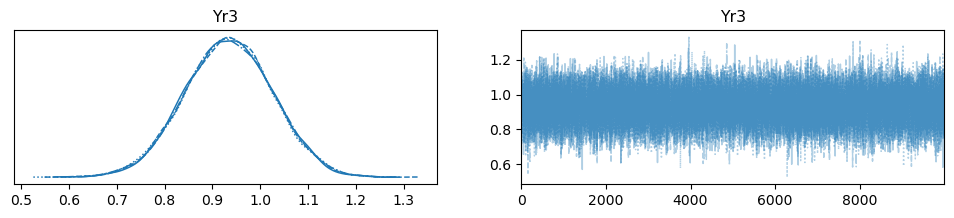

In [11]:
import arviz as az
import matplotlib.pyplot as plt

# trace plot for Yr3
az.plot_trace(uninf_results, var_names=["Yr3"])
plt.show()

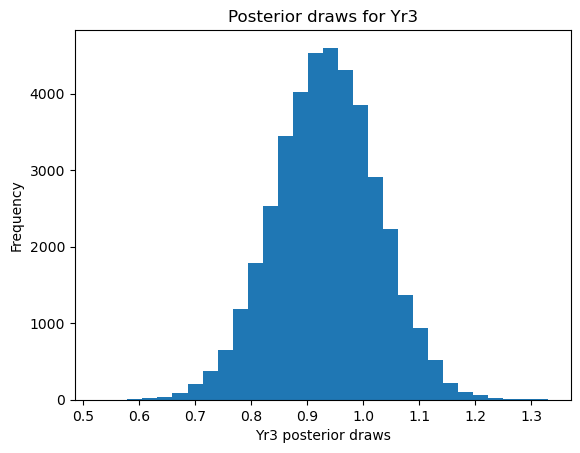

In [12]:
plt.hist(yr3_samples, bins=30)
plt.xlabel("Yr3 posterior draws")
plt.ylabel("Frequency")
plt.title("Posterior draws for Yr3")
plt.show()